In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Visual Settings
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('auto-mpg.csv')

# Display basic info to understand the structure
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [3]:
# 1. Clean 'horsepower' column: handle '?' and convert to float
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# 2. Impute missing values using the Median (Robust against outliers)
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# 3. Clean Origin column for better interpretability
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['origin'] = df['origin'].map(origin_map)

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [4]:
# Extract the brand (first word) from 'car name'
df['brand'] = df['car name'].str.split(' ').str[0].str.lower()

# Correct common spelling mistakes in car brands
brand_fixes = {
    'chevy': 'chevrolet', 'chevroelt': 'chevrolet',
    'maxda': 'mazda', 'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen'
}
df['brand'] = df['brand'].replace(brand_fixes)

# Drop the original 'car name' as it's no longer needed
df.drop('car name', axis=1, inplace=True)

# Apply One-Hot Encoding to categorical variables (Origin & Brand)
df = pd.get_dummies(df, columns=['origin', 'brand'], drop_first=True)

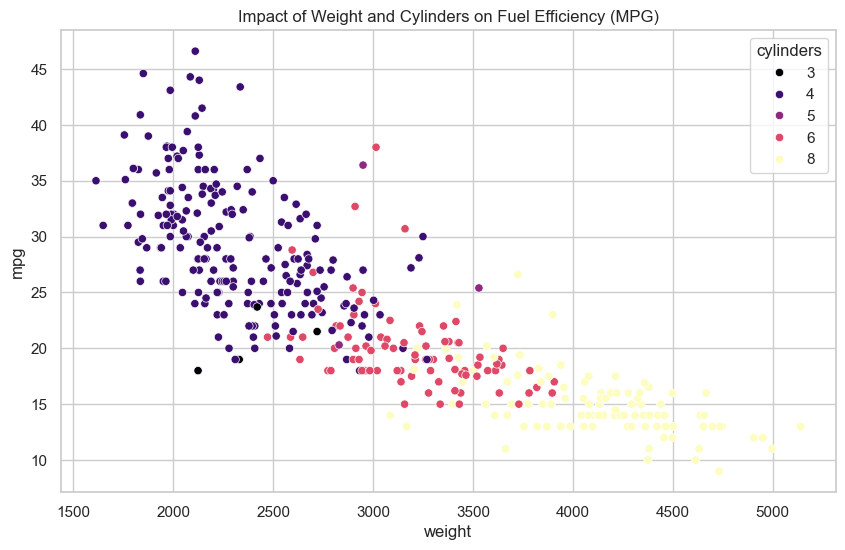

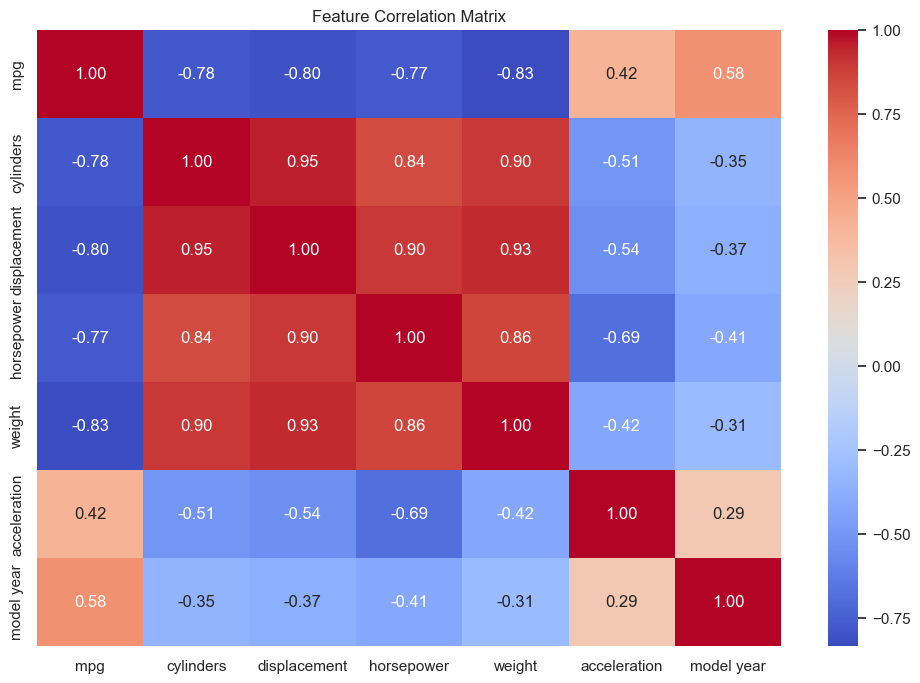

In [5]:
# Visualizing the relationship between Weight and MPG
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders', palette='magma')
plt.title('Impact of Weight and Cylinders on Fuel Efficiency (MPG)')
plt.show()

# Correlation Heatmap for key features
plt.figure(figsize=(12, 8))
sns.heatmap(df.iloc[:, :7].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [6]:
# Define Features (X) and Target (y)
X = df.drop('mpg', axis=1)
y = df['mpg']

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest Regressor
# Random Forest handles non-linear relationships better than Linear Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


Final Model Accuracy (R2 Score): 0.9124
MAE: 1.62 MPG
MSE: 2.17 MPG


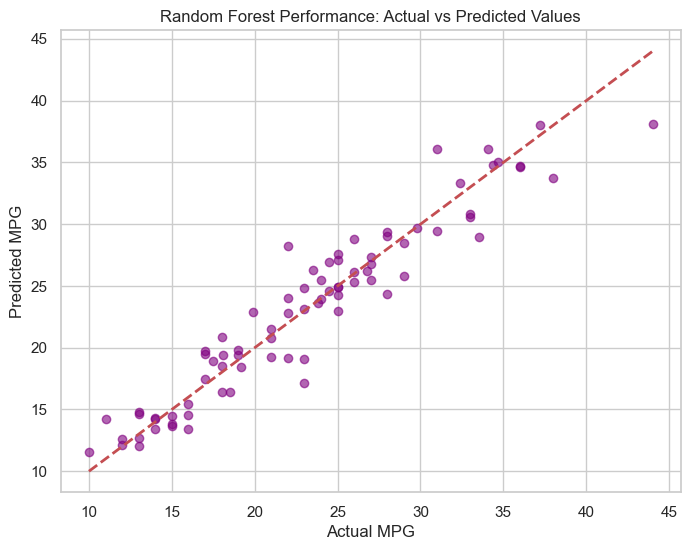

In [8]:
# Make Predictions
y_pred = rf_model.predict(X_test)

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Model Accuracy (R2 Score): {r2:.4f}")
print(f"MAE: {mae:.2f} MPG")
print(f"MSE: {rmse:.2f} MPG")

# Visual Comparison: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Random Forest Performance: Actual vs Predicted Values')
plt.show()